# ARIMAX (AutoRegressive Integrated Moving Average with Exogenous Variables)

ARIMAX is an extension of the traditional ARIMA model. While ARIMA models rely solely on the past values of the target variable to make forecasts, ARIMAX introduces Exogenous Variables—external factors that influence the target variable.

# Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
# Arima & Sarimax model from statsmodels
from statsmodels.tsa.statespace.sarimax import SARIMAX
# Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Create Sample Dataset

In [3]:
data = {
    'sales': [100, 110, 125, 130, 140,
              150, 160, 170, 180, 195,
              210, 220, 230, 245, 255],

    'ads': [10, 12, 13, 14, 15,
            16, 18, 19, 20, 22,
            23, 24, 25, 26, 28]
}

# Convert to Dataframe
df = pd.DataFrame(data)
df.head()

,sales,ads
0,100,10
1,110,12
2,125,13
3,130,14
4,140,15


# Visualize Data

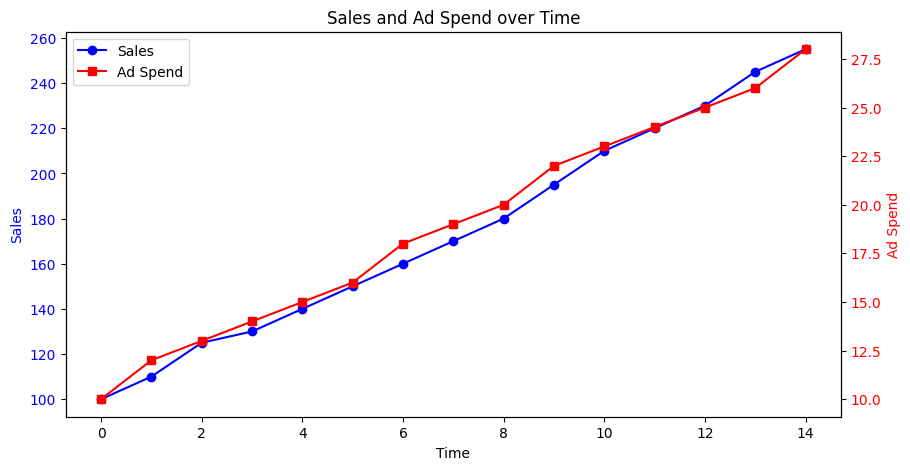

In [4]:
fig, ax1 = plt.subplots(figsize=(10, 5))

ax1.plot(df['sales'], marker='o', label='Sales', color='blue')
ax1.set_xlabel('Time')
ax1.set_ylabel('Sales', color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

ax2 = ax1.twinx() # Create a second y-axis that shares the same x-axis
ax2.plot(df['ads'], marker='s', label='Ad Spend', color='red')
ax2.set_ylabel('Ad Spend', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title("Sales and Ad Spend over Time")

# Combine legends from both axes
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.show()

# Split Data and Separate Variables

In [5]:
# Split Data into Train And Test
train = df[:12]
test = df[12:]

print(f'Training Shape:{train.shape}')
print(f'Testing Shape: {test.shape}\n')

Training Shape:(12, 2)
Testing Shape: (3, 2)



In [6]:
# Separate Target (y) and Exogenous (X) variables
y_train = train['sales']
y_test = test['sales']

X_train = train['ads']
X_test = test['ads']

# Build and Train ARIMAX Model

In [8]:
# Define model configuration
model = SARIMAX(
    y_train,
    exog=X_train,
    order=(1, 1, 1)
)

# Fit the model
model_fit = model.fit(disp=False)
print(model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                  sales   No. Observations:                   12
Model:               SARIMAX(1, 1, 1)   Log Likelihood                 -29.697
Date:                Mon, 25 May 2026   AIC                             67.393
Time:                        07:03:45   BIC                             68.985
Sample:                             0   HQIC                            66.390
                                 - 12                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ads            8.4761      0.448     18.928      0.000       7.598       9.354
ar.L1          0.0373      0.601      0.062      0.950      -1.141       1.215
ma.L1         -0.9996    320.119     -0.003      0.9

# Forecast Future Values

In [9]:
# Predict future values
predictions = model_fit.predict(
    start = len(train),
    end = len(train) + len(test) - 1,
    exog = X_test
)

print('Predicted Values:')
print(predictions)

Predicted Values:
12    224.091057
13    232.403556
14    249.349630
Name: predicted_mean, dtype: float64


# Evaluate and Plot Results

    Actual   Predicted
12     230  224.091057
13     245  232.403556
14     255  249.349630


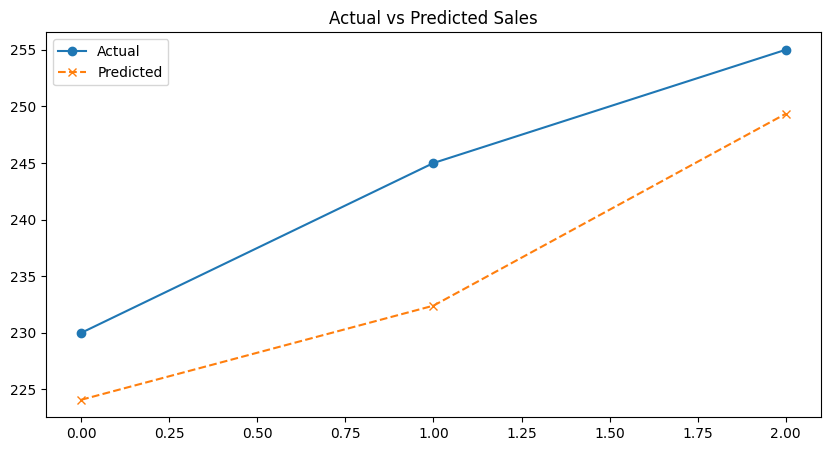

In [10]:
# Compare Actual vs Predicted
result = pd.DataFrame({
    'Actual': y_test,
    'Predicted': predictions
})
print(result)

# Plot Results
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label='Actual', marker='o')
plt.plot(predictions.values, label='Predicted', marker='x', linestyle='--')
plt.title("Actual vs Predicted Sales")
plt.legend()
plt.show()

# Performance Evaluation

In [11]:
mae = mean_absolute_error(y_test, predictions)
print(f"Mean Absolute Error (MAE): {mae:.2f}")

Mean Absolute Error (MAE): 8.05
